# Performance Comparison between Apache Spark RDDs and DataFrames for E-Commerce Analytics
# Abstract

This project investigates the performance differences between Apache Spark RDDs and DataFrames for big data analytics. The study was conducted using the Online Retail dataset, which contains transactional data from an international retail company. Two analytical tasks were implemented using both Spark abstractions: identifying the countries with the highest number of transactions and determining the best-selling products by quantity sold. Execution times and analytical results were compared to evaluate efficiency. The experiments demonstrate that DataFrames consistently outperform RDDs while producing identical results, highlighting the benefits of Spark SQL optimizations for large-scale data processing.

## Introduction

Apache Spark is one of the most widely used frameworks for big data processing and analytics. It provides different abstractions for handling large-scale datasets, including Resilient Distributed Datasets (RDDs) and DataFrames.

RDDs represent Spark's original low-level distributed data structure and offer flexibility for custom data processing. DataFrames provide a higher-level abstraction with schema support and query optimization capabilities through Spark SQL.

This project aims to compare the performance and usability of RDDs and DataFrames when performing common analytics tasks on an e-commerce dataset. The analysis is based on the Online Retail dataset, which contains transactional records including products, quantities, prices, customers, and countries.

### Research Question

Which Apache Spark abstraction, RDDs or DataFrames, provides better performance and usability for common e-commerce analytics tasks?

### Objectives

* Load and process the Online Retail dataset using Apache Spark.
* Implement the same analytics tasks using both RDDs and DataFrames.
* Measure execution times for each approach.
* Compare performance and ease of implementation.
* Discuss the advantages and limitations of each Spark abstraction.


# Dataset Description

The Online Retail dataset contains transactions occurring between December 2010 and December 2011 for a UK-based online retail company.

The dataset includes the following attributes:

* InvoiceNo: Invoice identifier.
* StockCode: Product identifier.
* Description: Product description.
* Quantity: Number of purchased items.
* InvoiceDate: Date and time of the transaction.
* UnitPrice: Price per unit.
* CustomerID: Customer identifier.
* Country: Customer country.

The dataset is suitable for big data analytics because it contains hundreds of thousands of transaction records and supports aggregation, filtering, and grouping operations commonly used in business intelligence applications.


# Spark Configuration

Apache Spark was configured within Google Colab using PySpark. A SparkSession was created to enable distributed data processing and analytics operations.

The experiments performed in this project compare the execution of common analytics tasks using two Spark abstractions:

* Resilient Distributed Datasets (RDDs)
* DataFrames

Execution times will be measured to evaluate the relative performance of both approaches.


In [4]:
!pip install pyspark

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RDD_vs_DataFrame") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


# Data Loading

The Online Retail dataset was uploaded into Google Colab and loaded into Apache Spark.

Both a DataFrame representation and an RDD representation were created in order to perform the same analytics tasks using the two Spark abstractions. This allows a direct comparison of performance and usability.


In [6]:
df = spark.read.csv(
    "online_retail.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

df.show(5)

+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01/12/2010 08:26|     2,55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01/12/2010 08:26|     2,75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
only showing top 5 rows


### Dataset Preview and Schema

The first five rows of the dataset are displayed to verify that the data has been loaded correctly. The schema is then examined to identify the available attributes and their corresponding data types before performing the analytical tasks.

In [7]:
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



### Dataset Overview

Before performing the analytical tasks, the size of the dataset is examined. The number of rows and columns provides an indication of the volume of data processed during the experiments.

In [8]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 541909
Number of columns: 8


### Conversion to RDD

To compare the two Spark abstractions, the DataFrame is converted into an RDD. The following experiments will be implemented using both approaches and their execution times will be measured.

In [ ]:
rdd = df.rdd

print("RDD created successfully")

RDD created successfully


#Experiment 1: Top Countries by Number of Transactions


### RDD Implementation

This section evaluates the use of Spark RDDs for common analytics tasks on the Online Retail dataset.

The first experiment consists of identifying the countries with the highest number of transactions.

In [ ]:
import time

start = time.time()

country_rdd = (
    rdd.map(lambda row: (row["Country"], 1))
       .reduceByKey(lambda a, b: a + b)
       .sortBy(lambda x: x[1], ascending=False)
)

top_countries_rdd = country_rdd.take(10)

end = time.time()

print("RDD Execution Time:", round(end - start, 4), "seconds")

for row in top_countries_rdd:
    print(row)

RDD Execution Time: 14.7964 seconds
('United Kingdom', 495478)
('Germany', 9495)
('France', 8557)
('EIRE', 8196)
('Spain', 2533)
('Netherlands', 2371)
('Belgium', 2069)
('Switzerland', 2002)
('Portugal', 1519)
('Australia', 1259)


### DataFrame Implementation

The same analytics task was implemented using Spark DataFrames in order to compare performance with the RDD approach.

In [ ]:
from pyspark.sql.functions import col
import time

start = time.time()

top_countries_df = (
    df.groupBy("Country")
      .count()
      .orderBy(col("count").desc())
)

top_countries_df.show(10)

end = time.time()

print("DataFrame Execution Time:",
      round(end - start, 4),
      "seconds")

+--------------+------+
|       Country| count|
+--------------+------+
|United Kingdom|495478|
|       Germany|  9495|
|        France|  8557|
|          EIRE|  8196|
|         Spain|  2533|
|   Netherlands|  2371|
|       Belgium|  2069|
|   Switzerland|  2002|
|      Portugal|  1519|
|     Australia|  1259|
+--------------+------+
only showing top 10 rows
DataFrame Execution Time: 4.0642 seconds


### Observation

Both implementations produced identical country rankings. However, the DataFrame implementation completed the task significantly faster than the RDD implementation.

# Results Comparison

The same analytics task was implemented using both Spark RDDs and DataFrames.

The RDD implementation required approximately 14.80 seconds, while the DataFrame implementation completed in approximately 4.06 seconds.

The results show that DataFrames significantly outperform RDDs for aggregation and grouping operations. This performance advantage is mainly due to Spark SQL optimizations and the Catalyst Optimizer, which automatically improves query execution plans.

Although RDDs provide greater flexibility and lower-level control, DataFrames offer better performance and simpler syntax for analytical workloads.

Therefore, for this experiment, DataFrames proved to be the most efficient solution.

# Experiment 2: Top Products by Quantity Sold

The objective of this experiment is to identify the products with the highest quantities sold and compare the execution time of RDDs and DataFrames for another aggregation task.

### RDD Implementation

The task is first implemented using Spark RDDs. The dataset is transformed into key-value pairs where the product description is used as the key and the quantity sold as the value. Quantities are aggregated using reduceByKey and the results are sorted in descending order.

In [ ]:
import time

start = time.time()

top_products_rdd = (
    rdd.map(lambda row: (row["Description"], row["Quantity"]))
       .reduceByKey(lambda a, b: a + b)
       .sortBy(lambda x: x[1], ascending=False)
)

result_rdd = top_products_rdd.take(10)

end = time.time()

print("RDD Execution Time:", round(end - start, 4), "seconds")

for row in result_rdd:
    print(row)

RDD Execution Time: 14.0985 seconds
('WORLD WAR 2 GLIDERS ASSTD DESIGNS', 53847)
('JUMBO BAG RED RETROSPOT', 47363)
('ASSORTED COLOUR BIRD ORNAMENT', 36381)
('POPCORN HOLDER', 36334)
('PACK OF 72 RETROSPOT CAKE CASES', 36039)
('WHITE HANGING HEART T-LIGHT HOLDER', 35317)
('RABBIT NIGHT LIGHT', 30680)
('MINI PAINT SET VINTAGE ', 26437)
('PACK OF 12 LONDON TISSUES ', 26315)
('PACK OF 60 PINK PAISLEY CAKE CASES', 24753)


### DataFrame Implementation

The same task is then implemented using Spark DataFrames. Product quantities are aggregated using groupBy and sum operations, followed by sorting in descending order based on the total quantity sold.

In [ ]:
from pyspark.sql.functions import sum, col
import time

start = time.time()

top_products_df = (
    df.groupBy("Description")
      .agg(sum("Quantity").alias("TotalQuantity"))
      .orderBy(col("TotalQuantity").desc())
)

top_products_df.show(10, truncate=False)

end = time.time()

print("DataFrame Execution Time:",
      round(end - start, 4),
      "seconds")

+----------------------------------+-------------+
|Description                       |TotalQuantity|
+----------------------------------+-------------+
|WORLD WAR 2 GLIDERS ASSTD DESIGNS |53847        |
|JUMBO BAG RED RETROSPOT           |47363        |
|ASSORTED COLOUR BIRD ORNAMENT     |36381        |
|POPCORN HOLDER                    |36334        |
|PACK OF 72 RETROSPOT CAKE CASES   |36039        |
|WHITE HANGING HEART T-LIGHT HOLDER|35317        |
|RABBIT NIGHT LIGHT                |30680        |
|MINI PAINT SET VINTAGE            |26437        |
|PACK OF 12 LONDON TISSUES         |26315        |
|PACK OF 60 PINK PAISLEY CAKE CASES|24753        |
+----------------------------------+-------------+
only showing top 10 rows
DataFrame Execution Time: 5.0729 seconds


### Observation

Both implementations produced identical rankings of the top-selling products. However, the DataFrame implementation required less execution time, demonstrating the efficiency of Spark SQL optimizations for aggregation tasks.

## Interpretation

The analysis identified the products with the highest quantities sold in the dataset.

The product "WORLD WAR 2 GLIDERS ASSTD DESIGNS" achieved the highest sales volume, followed by "JUMBO BAG RED RETROSPOT" and several other popular retail products.

Comparing execution times allows us to evaluate the efficiency of Spark DataFrames relative to RDDs for aggregation-based analytics tasks.

# Results Comparison

Both implementations produced exactly the same ranking of the best-selling products.

However, the DataFrame implementation completed the task significantly faster than the RDD implementation.

RDD Execution Time: 14.10 seconds

DataFrame Execution Time: 5.07 seconds

This confirms that Spark DataFrames benefit from query optimization mechanisms such as Catalyst Optimizer and Tungsten Execution Engine, resulting in better performance for aggregation operations.

While RDDs provide greater control over data processing, DataFrames are generally preferable for analytical workloads because they offer simpler code and higher execution efficiency.

## Performance Visualization

The following chart summarizes the execution times obtained for the RDD and DataFrame implementations in both analytical tasks. This visualization provides a direct comparison of the performance differences between the two Spark abstractions.


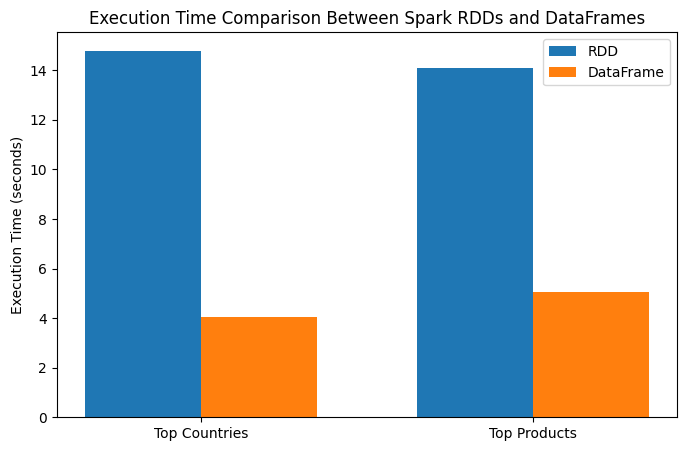

In [3]:
import matplotlib.pyplot as plt

tasks = ["Top Countries", "Top Products"]
rdd_times = [14.7964, 14.0985]
df_times = [4.0642, 5.0739]

x = range(len(tasks))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], rdd_times, width=width, label="RDD")
plt.bar([i + width/2 for i in x], df_times, width=width, label="DataFrame")

plt.xticks(x, tasks)
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison Between Spark RDDs and DataFrames")
plt.legend()

plt.show()

### Observation

The chart confirms that DataFrames consistently achieved lower execution times than RDDs for both analytical tasks. The performance improvement is particularly noticeable for the country ranking task, where the DataFrame implementation completed the computation in approximately one third of the RDD execution time.

These results highlight the benefits of Spark SQL optimizations and demonstrate that DataFrames are generally more efficient for analytical workloads.

# Conclusion

This project explored the performance differences between Spark RDDs and Spark DataFrames using the Online Retail dataset.

Two analytical experiments were conducted:

1. Identification of the countries with the highest number of transactions.
2. Identification of the products with the highest quantities sold.

For both experiments, the DataFrame implementation consistently outperformed the RDD implementation while producing identical analytical results.

The first experiment showed that DataFrames were approximately 3.6 times faster than RDDs. The second experiment demonstrated a performance improvement of approximately 2.8 times.

These results confirm that Spark DataFrames are generally the preferred abstraction for big data analytics tasks due to their optimized execution engine, concise syntax, and superior performance.

RDDs remain useful when low-level transformations and custom processing are required, but for most analytical workloads DataFrames provide a more efficient solution.

# References

[1] Apache Spark Documentation.
https://spark.apache.org/docs/latest/

[2] Zaharia, M. et al. Apache Spark: A Unified Engine for Big Data Processing.

[3] Online Retail Dataset.
UCI Machine Learning Repository.
https://archive.ics.uci.edu/